Andhika Daffa Athaaillah
02
244107020223

In [6]:
!pip install -q ucimlrepo

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [8]:
adult_income = fetch_ucirepo(id=2)

In [12]:
X = adult_income.data.features
y = adult_income.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [13]:
df.shape

(48842, 15)

In [14]:
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation


## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?

In [ ]:
print(df.info())
df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)
missing_counts = df.isnull().sum()
print("\nVariables with missing values:")
print(missing_counts[missing_counts > 0])

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB
None

Variables with missing values:
workclass         2799
occupation        2809
native-country     857
dtype: int64


## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 6465


C:\Users\andhi\AppData\Local\Temp\ipykernel_40052\925494745.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [15]:
df['workclass'] = df['workclass'].str.strip()
df['occupation'] = df['occupation'].str.strip()
df['native-country'] = df['native-country'].str.strip()


df['capital-gain'] = df['capital-gain'].astype(str)
df.loc[df['capital-gain'] == '99999', 'capital-gain'] = 'Others'

print("Inappropriate values replaced.")

Inappropriate values replaced.


# Part 2 - Visual Inspection

## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

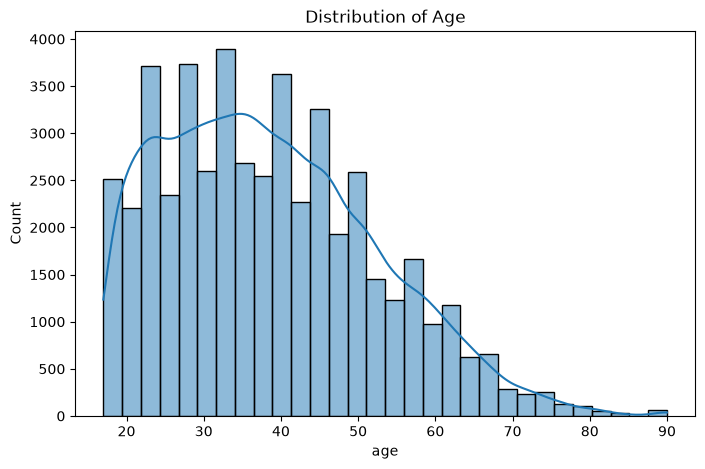

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.show()

C:\Users\andhi\AppData\Local\Temp\ipykernel_40052\1123870704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['education'], order=df['education'].value_counts().index, palette='viridis')


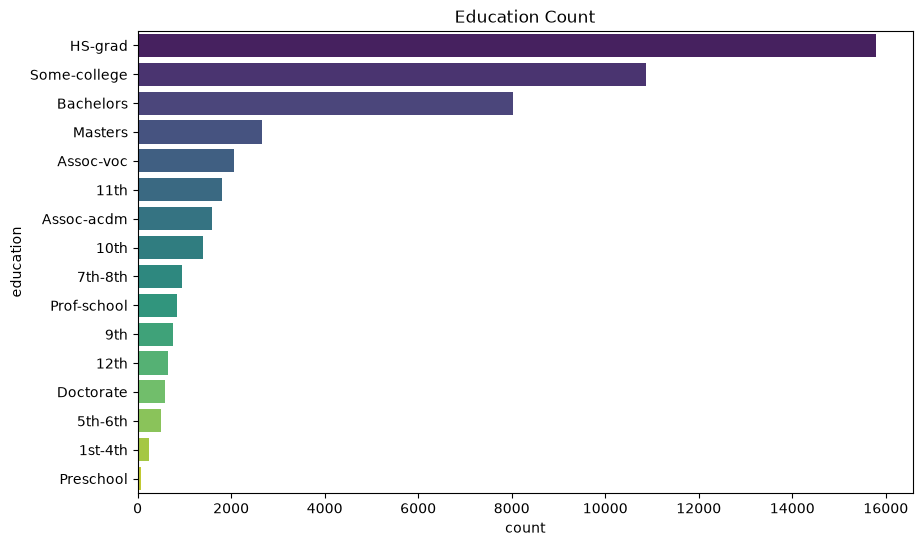

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df['education'], order=df['education'].value_counts().index, palette='viridis')
plt.title('Education Count')
plt.show()

C:\Users\andhi\AppData\Local\Temp\ipykernel_40052\4249892004.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')


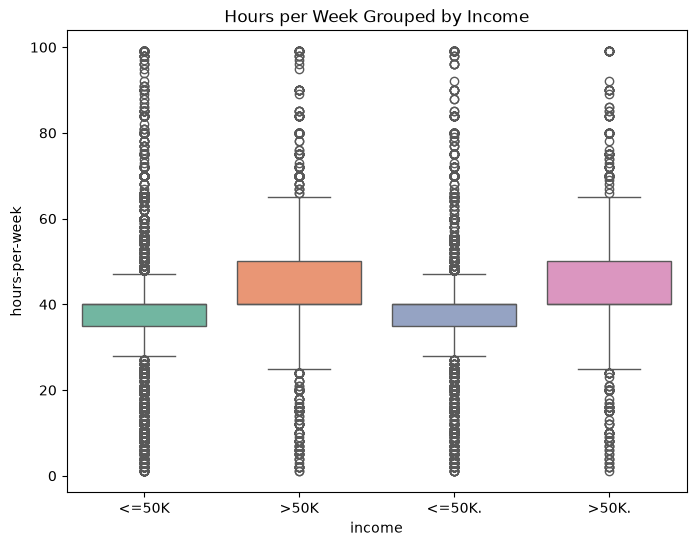

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')
plt.title('Hours per Week Grouped by Income')
plt.show()

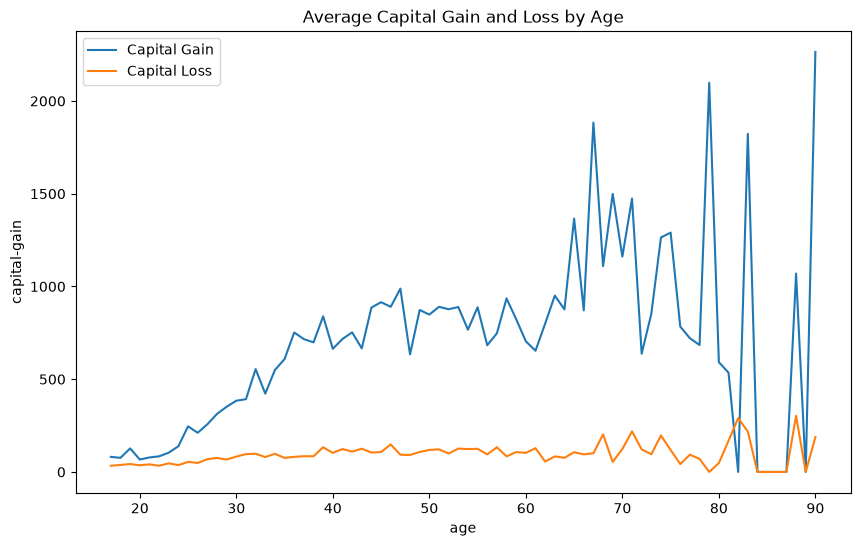

In [ ]:
plt.figure(figsize=(10, 6))

plot_df = df.copy()
plot_df['capital-gain'] = pd.to_numeric(plot_df['capital-gain'], errors='coerce').fillna(0)

age_grouped = plot_df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()
sns.lineplot(data=age_grouped, x='age', y='capital-gain', label='Capital Gain')
sns.lineplot(data=age_grouped, x='age', y='capital-loss', label='Capital Loss')
plt.title('Average Capital Gain and Loss by Age')
plt.legend()
plt.show()

## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

In [ ]:
# Answer with python comment like this -> inline comment

'''
1. The 'age' variable shows a right-skewed (positive) distribution, with a long tail extending into the older age ranges.
2. Because 'age' is right-skewed, the median is the best data imputation method. It is robust to the extreme values in the long tail, whereas the mean would be artificially pulled higher.
3. Both income categories contain outliers in 'hours-per-week', but the '<=50K' category has significantly more outliers (especially on the lower end) because it captures a much wider and more varied demographic of part-time and unconventional workers.
'''

'\n  Or by using multiple\n  line comments like this\n'

# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


df['sex'] = le.fit_transform(df['sex'])
df['income'] = le.fit_transform(df['income'])

print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

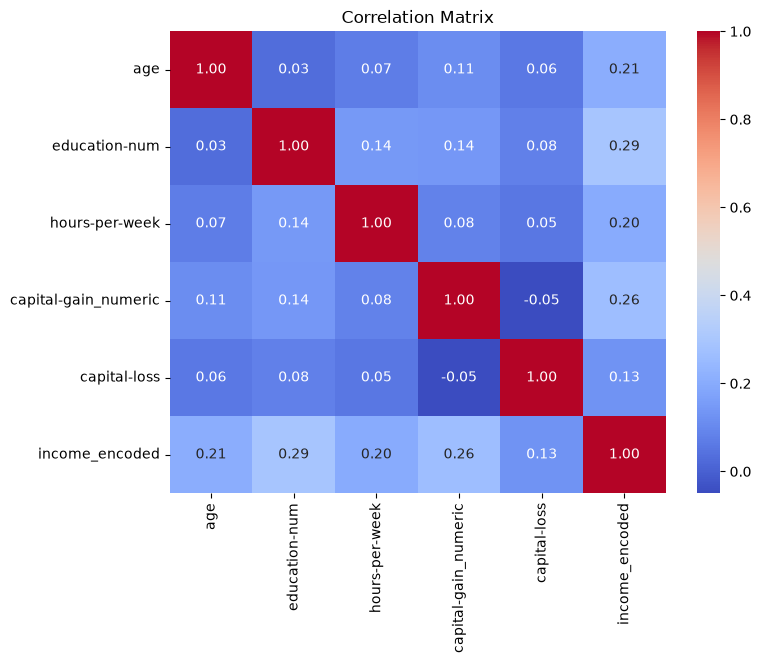

In [ ]:
corr_vars = ['age', 'education-num', 'hours-per-week', 'capital-loss', 'income_encoded']

df['capital-gain_numeric'] = pd.to_numeric(df['capital-gain'], errors='coerce').fillna(0)
corr_vars.insert(3, 'capital-gain_numeric')

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Task 2

In [ ]:
'''
Based on the correlation matrix results:
1. 'education-num' has the strongest positive correlation with 'income_encoded', indicating that higher education levels are the best predictor of higher income.
2. 'age' and 'hours-per-week' also show moderate positive correlations with income.
3. 'capital-gain' and 'capital-loss' have very weak linear correlations with the other variables, largely because they are sparse (mostly zeros for the majority of the dataset).
'''

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


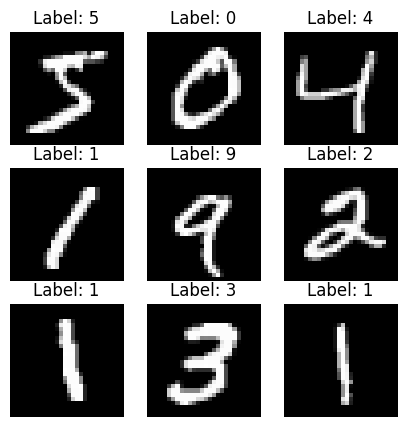

In [ ]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

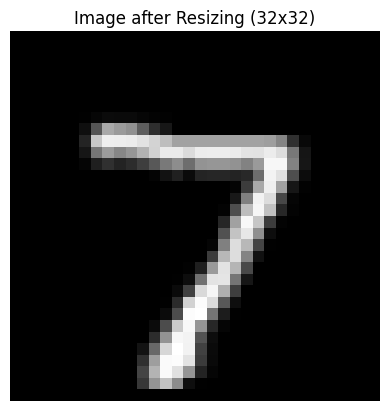

In [11]:
import cv2

resized_images = []

for img in X_test:
    img_resized = cv2.resize(img, (32, 32))
    resized_images.append(img_resized)

X_test_32 = np.array(resized_images)

plt.imshow(X_test_32[0], cmap="gray")
plt.title("Image after Resizing (32x32)")
plt.axis("off")
plt.show()

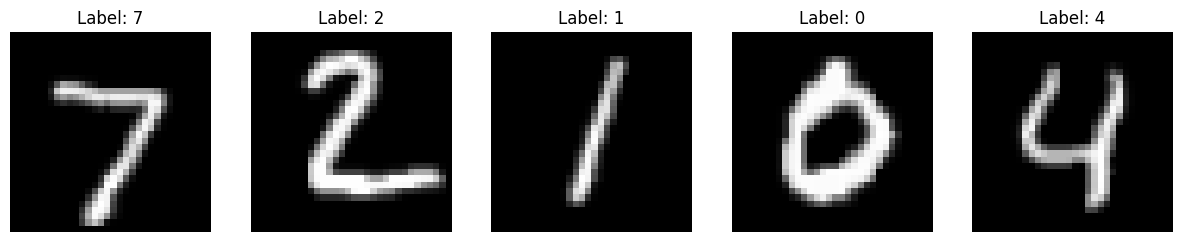

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_32[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.show()

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [3]:
X_test_norm = X_test_32 / 255.0

print(f"Max pixel value after normalization: {X_test_norm.max()}")
print(f"Min pixel value after normalization: {X_test_norm.min()}")

Max pixel value after normalization: 1.0
Min pixel value after normalization: 0.0


## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [4]:
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print("Original Shape:", X_test_norm.shape)
print("Flattened Shape:", X_test_flat.shape)

Original Shape: (10000, 32, 32)
Flattened Shape: (10000, 1024)
